# Phase 3 — Improved CNN

In [1]:
import sys
sys.path.append('../src')

import json as jsonlib
import torch
import torch.nn as nn

from config import SEED, MODELS_DIR, LOGS_DIR, PLOTS_DIR, IMPROVED_EPOCHS, LEARNING_RATE
from data_loader import get_dataloaders
from models.baseline_cnn import BaselineCNN
from models.improved_cnn import ImprovedCNN
from train import set_seed, run_training, evaluate

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


## 1. Load data

In [2]:
train_loader, val_loader, test_loader, class_mapping = get_dataloaders()
num_classes = len(class_mapping)
idx_to_class = {v: k for k, v in class_mapping.items()}

print(f"Classes: {num_classes}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")


Classes: 38
Train batches: 1188 | Val batches: 255 | Test batches: 256


## 2. Build model — parameter comparison vs baseline

In [3]:
model = ImprovedCNN(num_classes=num_classes).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"ImprovedCNN parameters: {n_params:,}")

baseline_ref = BaselineCNN(num_classes=num_classes)
n_baseline_params = sum(p.numel() for p in baseline_ref.parameters())
print(f"BaselineCNN parameters: {n_baseline_params:,}")

# Shape check with a real batch
images, labels = next(iter(train_loader))
images = images.to(device)
with torch.no_grad():
    out = model(images)
print(f"\nInput shape: {images.shape} -> Output shape: {out.shape}")


ImprovedCNN parameters: 1,711,654
BaselineCNN parameters: 2,348,006


g:\Project CNN\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Input shape: torch.Size([32, 3, 128, 128]) -> Output shape: torch.Size([32, 38])


## 3. Train

In [4]:
history, best_ckpt_path = run_training(
    model=model,
    model_name='improved',
    epochs=IMPROVED_EPOCHS,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    checkpoint_dir=MODELS_DIR / 'improved',
    lr=LEARNING_RATE,
)


Training improved on cpu for up to 25 epochs (early stopping patience=5)

Epoch  1/25 | train_loss=1.5045 train_acc=0.5435 | val_loss=0.9472 val_acc=0.6966 | 1006.2s
  -> val_loss improved, checkpoint saved to G:\Project CNN\models\improved\improved_best.pt
Epoch  2/25 | train_loss=0.7030 train_acc=0.7710 | val_loss=0.4596 val_acc=0.8438 | 859.5s
  -> val_loss improved, checkpoint saved to G:\Project CNN\models\improved\improved_best.pt
Epoch  3/25 | train_loss=0.4827 train_acc=0.8411 | val_loss=0.4060 val_acc=0.8653 | 748.9s
  -> val_loss improved, checkpoint saved to G:\Project CNN\models\improved\improved_best.pt
Epoch  4/25 | train_loss=0.3820 train_acc=0.8742 | val_loss=0.3621 val_acc=0.8772 | 713.4s
  -> val_loss improved, checkpoint saved to G:\Project CNN\models\improved\improved_best.pt
Epoch  5/25 | train_loss=0.3231 train_acc=0.8926 | val_loss=0.1519 val_acc=0.9486 | 721.7s
  -> val_loss improved, checkpoint saved to G:\Project CNN\models\improved\improved_best.pt
Epoch  6/2

## 4. Baseline vs Improved — side-by-side curves

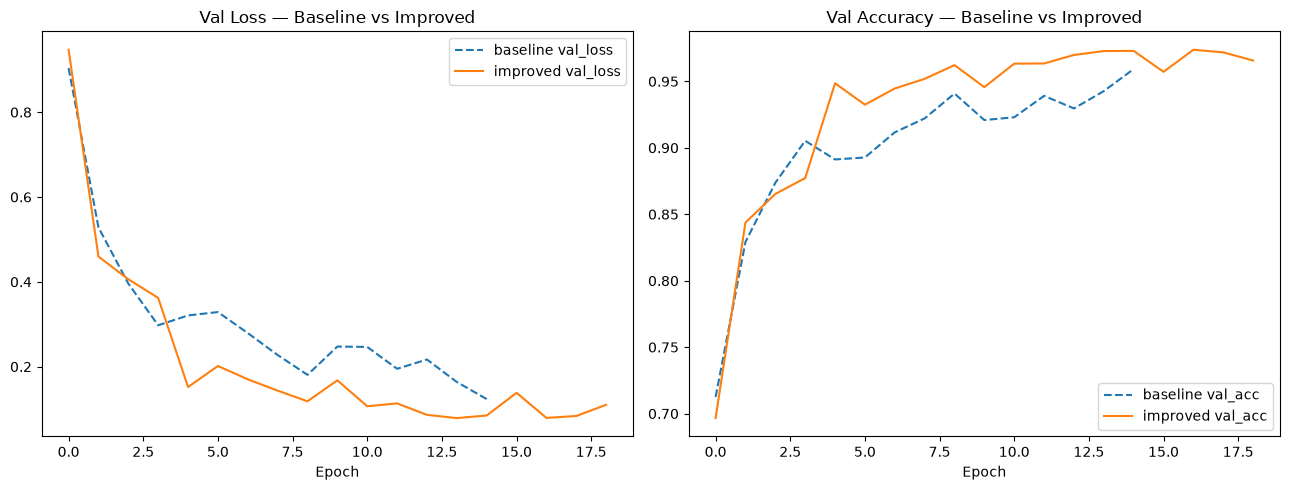

Baseline best val_loss : 0.1236  (epoch 15)
Improved best val_loss : 0.0787  (epoch 14)


In [5]:
import matplotlib.pyplot as plt

with open(LOGS_DIR / 'baseline_history.json') as f:
    baseline_history = jsonlib.load(f)
with open(LOGS_DIR / 'improved_history.json') as f:
    improved_history = jsonlib.load(f)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(baseline_history['val_loss'], label='baseline val_loss', linestyle='--')
axes[0].plot(improved_history['val_loss'], label='improved val_loss')
axes[0].set_title('Val Loss — Baseline vs Improved')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(baseline_history['val_acc'], label='baseline val_acc', linestyle='--')
axes[1].plot(improved_history['val_acc'], label='improved val_acc')
axes[1].set_title('Val Accuracy — Baseline vs Improved')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'baseline_vs_improved_curves.png', dpi=150)
plt.show()

print(f"Baseline best val_loss : {min(baseline_history['val_loss']):.4f}  (epoch {baseline_history['val_loss'].index(min(baseline_history['val_loss']))+1})")
print(f"Improved best val_loss : {min(improved_history['val_loss']):.4f}  (epoch {improved_history['val_loss'].index(min(improved_history['val_loss']))+1})")


## 5. Test set — final comparison

In [6]:
model.load_state_dict(torch.load(best_ckpt_path))
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Improved — Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")
print(f"\n(Baseline was — Test loss: 0.1065 | Test accuracy: 0.9643 — for reference)")

print(f"\nImproved train/val gap (final epoch): "
      f"{improved_history['val_acc'][-1] - improved_history['train_acc'][-1]:+.4f}")
print(f"Baseline train/val gap (final epoch): "
      f"{baseline_history['val_acc'][-1] - baseline_history['train_acc'][-1]:+.4f}")


Improved — Test loss: 0.0741 | Test accuracy: 0.9763

(Baseline was — Test loss: 0.1065 | Test accuracy: 0.9643 — for reference)

Improved train/val gap (final epoch): +0.0004
Baseline train/val gap (final epoch): +0.0358


## 6. Quick per-class check

In [7]:
from collections import defaultdict

model.eval()
class_correct = defaultdict(int)
class_total = defaultdict(int)

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(dim=1)
        for p, l in zip(preds.cpu().tolist(), labels.cpu().tolist()):
            class_total[l] += 1
            if p == l:
                class_correct[l] += 1

watch_classes = ['Potato___healthy', 'Apple___Cedar_apple_rust', 'Peach___healthy']
for cname in watch_classes:
    if cname in class_mapping:
        idx = class_mapping[cname]
        acc = class_correct[idx] / class_total[idx] if class_total[idx] else float('nan')
        print(f"{cname:40s}: {acc:.4f}  ({class_correct[idx]}/{class_total[idx]})")


Potato___healthy                        : 1.0000  (24/24)
Apple___Cedar_apple_rust                : 1.0000  (42/42)
Peach___healthy                         : 1.0000  (55/55)
